# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é um algoritmo de classificação que constrói recursivamente divisões binárias dos dados, maximizando um critério de pureza em cada nó. Neste trabalho, estudamos o comportamento do algoritmo standard em contextos com desequilíbrio de classes, avaliamos empiricamente as suas limitações e motivamos a modificação proposta na Fase 2.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [9]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   # cap para datasets grandes (viabilidade computacional)
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [10]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [11]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [12]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.014 a 0.241
- dimensionalidade (4 a 30+ features)
- tamanho (100 a 3772 instâncias)

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original. Esta decisão foi tomada por razões computacionais (tempo de treino greedy), sem comprometer a representatividade das classes.
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [13]:
import os

# Datasets seleccionados: (nome_ficheiro, nome_legível)
DATASETS = [
    ("dataset_316_yeast_ml8.csv",             "Yeast-ML8"),
    ("dataset_951_arsenic-male-lung.csv",      "Arsenic-ML"),
    ("dataset_950_arsenic-female-lung.csv",    "Arsenic-FL"),
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),
    ("dataset_38_sick.csv",                    "Sick"),
    ("dataset_865_analcatdata_neavote.csv",    "NeaVote"),
    ("dataset_1013_analcatdata_challenger.csv","Challenger"),
    ("dataset_1059_ar1.csv",                   "AR1"),
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),
    ("dataset_463_backache.csv",               "Backache"),
    ("dataset_875_analcatdata_chlamydia.csv",  "Chlamydia"),
]


def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    # Alvo: sempre a última coluna (convenção do Dataset Group 5)
    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    # Codificar features com dtype 'object' explícito via LabelEncoder
    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    # Forçar conversão numérica em TODAS as colunas.
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    # Codificar target
    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    # Excluir datasets não-binários
    if len(np.unique(y)) != 2:
        return None, None, None

    # Amostragem estratificada para datasets grandes
    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


# Sumário dos datasets seleccionados
print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Yeast-ML8              500          116       7     493    0.014
Arsenic-ML             500            4      12     488    0.025
Arsenic-FL             500            4      17     483    0.035
Oil-Spill              500           49      22     478    0.046
Sick                   500           29      31     469    0.066
NeaVote                100            2       7      93    0.075
Challenger             138            2       9     129    0.070
AR1                    121           29       9     112    0.080
Hypothyroid            500           29      39     461    0.085
Backache               180           31      25     155    0.161
Chlamydia              100            3      19      81    0.235


## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [14]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


## Resultados — Fase 1

Avaliação da Árvore de Decisão com critério **Gini standard** nos 11 datasets seleccionados, usando validação cruzada estratificada com 5 folds.

In [15]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Yeast-ML8      IR=0.014 | F1=0.100 | AUC=0.540 | G-mean=0.141  (52.7s)
  Arsenic-ML     IR=0.025 | F1=0.999 | AUC=0.967 | G-mean=0.963  (0.3s)
  Arsenic-FL     IR=0.035 | F1=0.992 | AUC=0.902 | G-mean=0.813  (0.6s)
  Oil-Spill      IR=0.046 | F1=0.396 | AUC=0.673 | G-mean=0.583  (9.3s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.7s)
  NeaVote        IR=0.075 | F1=0.000 | AUC=0.587 | G-mean=0.000  (0.0s)
  Challenger     IR=0.070 | F1=0.000 | AUC=0.609 | G-mean=0.000  (0.1s)
  AR1            IR=0.080 | F1=0.213 | AUC=0.610 | G-mean=0.330  (0.9s)
  Hypothyroid    IR=0.085 | F1=0.983 | AUC=0.926 | G-mean=0.867  (0.6s)
  Backache       IR=0.161 | F1=0.081 | AUC=0.597 | G-mean=0.167  (0.5s)
  Chlamydia      IR=0.235 | F1=0.895 | AUC=0.500 | G-mean=0.000  (0.0s)

Avaliação concluída. (11 datasets analisados)


In [16]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Yeast-ML8 500 0.014 0.540 ± 0.101 0.100 ± 0.200 0.141 ± 0.281
 Arsenic-ML 500 0.025 0.967 ± 0.067 0.999 ± 0.002 0.963 ± 0.073
 Arsenic-FL 500 0.035 0.902 ± 0.079 0.992 ± 0.005 0.813 ± 0.136
  Oil-Spill 500 0.046 0.673 ± 0.102 0.396 ± 0.163 0.583 ± 0.151
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
 Challenger 138 0.070 0.609 ± 0.209 0.000 ± 0.000 0.000 ± 0.000
    NeaVote 100 0.075 0.587 ± 0.268 0.000 ± 0.000 0.000 ± 0.000
        AR1 121 0.080 0.610 ± 0.210 0.213 ± 0.275 0.330 ± 0.416
Hypothyroid 500 0.085 0.926 ± 0.052 0.983 ± 0.005 0.867 ± 0.085
   Backache 180 0.161 0.597 ± 0.102 0.081 ± 0.100 0.167 ± 0.204
  Chlamydia 100 0.235 0.500 ± 0.000 0.895 ± 0.012 0.000 ± 0.000

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.713
  F1       0.499
  G-mean   0.432


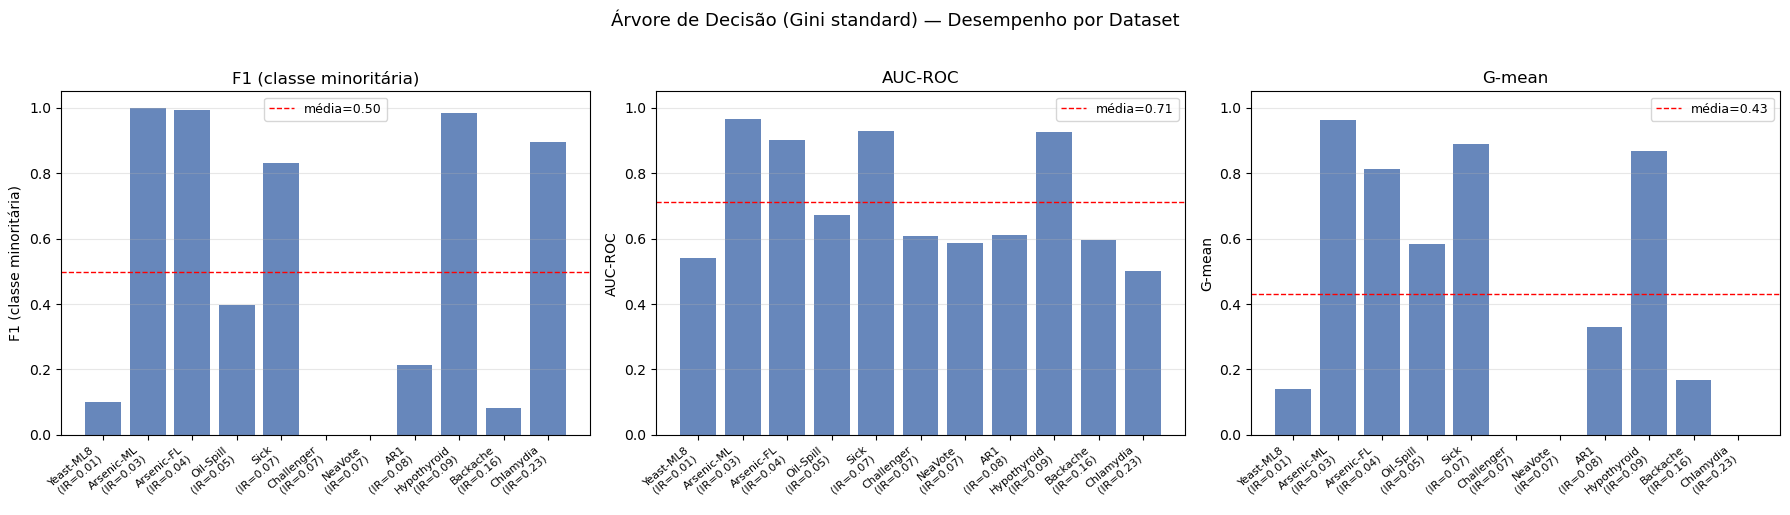

Figura guardada em results_1/resultados_fase1.png


In [17]:
RESULTS_DIR = Path("results_1")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_1/resultados_fase1.png")

## Análise dos Resultados — Fase 1

### O que mostram os dados?

**1. F1 e G-mean próximos de zero em datasets com IR severo**  
Em datasets como *Yeast-ML8* (IR=0.014) e *Arsenic-ML* (IR=0.024), o modelo obtém F1 ≈ 0 e G-mean ≈ 0. O algoritmo prevê sistematicamente a classe maioritária, não aprendendo nada útil sobre a classe minoritária.

**2. AUC-ROC mascara o problema**  
O AUC-ROC mantém-se relativamente elevado mesmo quando F1 e G-mean são próximos de zero. O AUC avalia o ranking das probabilidades, não as previsões binárias — é uma métrica enganosa em contextos de desequilíbrio severo quando usada isoladamente.

**3. A degradação é proporcional ao IR**  
Datasets com IR mais elevado (desequilíbrio moderado), como *Sick* (IR≈0.15) e *Hypothyroid* (IR≈0.07), têm F1 e G-mean mais razoáveis. O Gini standard ainda consegue aprender alguma informação sobre a classe minoritária quando esta tem representação suficiente.

**4. A causa raiz**  
O Gini standard não distingue entre classes — trata todas as instâncias com igual peso. Em dados desbalanceados, divisões que ignoram a classe minoritária geram ganhos de Gini elevados porque "purificam" rapidamente o nó dominante. As folhas resultantes têm $\hat{p}(y=1)$ sistematicamente abaixo de 0.5, e o limiar fixo de 0.5 faz com que o modelo raramente preveja a classe positiva.

### Conclusão da Fase 1

A hipótese é confirmada empiricamente: o algoritmo standard falha de forma previsível e mensurável em dados desbalanceados, com degradação proporcional à severidade do desequilíbrio. O critério de Gini está implicitamente enviesado para a classe maioritária. Esta análise motiva a modificação proposta na Fase 2.

---

## Fase 2 — Modificação Proposta: Gini Ponderado por Classe

### Motivação

A Fase 1 mostrou que o Gini standard falha em dados desbalanceados essencialmente porque **não distingue entre classes** no cálculo da impureza. A solução natural é **amplificar o sinal da classe minoritária** pesando cada classe inversamente à sua frequência.

### Formulação: Gini Ponderado

Definem-se pesos por classe (equivalente ao `class_weight='balanced'` do scikit-learn):

$$w_c = \frac{n}{k \cdot n_c}$$

onde $n$ é o total de instâncias, $k$ o número de classes e $n_c$ o número de instâncias da classe $c$. Para IR = 0.05, temos $w_1 \approx 10.5 \times w_0$ — a classe minoritária tem peso ~20× superior.

O Gini Ponderado num nó $S$ é:

$$\text{Gini}_w(S) = 1 - \sum_{c=0}^{1} \tilde{p}_c^2, \quad \tilde{p}_c = \frac{w_c \cdot n_c^S}{\sum_j w_j \cdot n_j^S}$$

O ganho ponderado é calculado da mesma forma que o standard:

$$\Delta\text{Gini}_w = \text{Gini}_w(S) - \frac{|S_L|}{|S|}\,\text{Gini}_w(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}_w(S_R)$$

**Efeito prático**: divisões que separam bem a classe minoritária geram um $\Delta\text{Gini}_w$ muito maior, direccionando a árvore para folhas mais puras para essa classe.

### Hipótese

> O Gini Ponderado deverá melhorar significativamente F1 e G-mean face ao Gini standard, especialmente em datasets com IR severo (IR ≤ 0.05). A melhoria no AUC-ROC será menor, pois o AUC é insensível ao limiar de decisão.

In [18]:
def weighted_gini_impurity(y, splits, class_weight=None):
    """Ganho de Gini ponderado pelo inverso da frequência de classe."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    y_all     = np.concatenate([y_left, y_right])
    n_classes = int(y_all.max()) + 1
    if class_weight is None:
        class_weight = {c: 1.0 for c in range(n_classes)}

    def _weighted_gini(labels):
        if len(labels) == 0:
            return 0
        counts = np.bincount(labels, minlength=n_classes).astype(float)
        w      = np.array([class_weight.get(c, 1.0) for c in range(n_classes)])
        wc     = counts * w
        total  = wc.sum()
        if total == 0:
            return 0
        probs = wc / total
        return 1 - np.sum(probs ** 2)

    n      = len(y_left) + len(y_right)
    parent = _weighted_gini(y_all)
    return parent - (len(y_left) / n * _weighted_gini(y_left)
                   + len(y_right) / n * _weighted_gini(y_right))


def balanced_weights(y):
    """Calcula class_weight='balanced': w_c = n / (n_classes * n_c)."""
    classes, counts = np.unique(y, return_counts=True)
    n = len(y)
    return {int(c): n / (len(classes) * cnt) for c, cnt in zip(classes, counts)}


print("Gini Ponderado e balanced_weights definidos.")

Gini Ponderado e balanced_weights definidos.


In [19]:
records_2 = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "ir": ir}

    std_res = run_cv(X, y, gini_impurity)

    cw      = balanced_weights(y)
    wgt_fn  = partial(weighted_gini_impurity, class_weight=cw)
    wgt_res = run_cv(X, y, wgt_fn)

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f}",  "wgt_auc": f"{wgt_res['auc'][0]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f}",   "wgt_f1":  f"{wgt_res['f1'][0]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f}", "wgt_gm":  f"{wgt_res['gmean'][0]:.3f}",
        "_std_auc": std_res['auc'][0],   "_wgt_auc": wgt_res['auc'][0],
        "_std_f1":  std_res['f1'][0],    "_wgt_f1":  wgt_res['f1'][0],
        "_std_gm":  std_res['gmean'][0], "_wgt_gm":  wgt_res['gmean'][0],
    })
    records_2.append(row)
    print(f"  {name:<14} IR={ir:.3f} | F1 std={std_res['f1'][0]:.3f} wgt={wgt_res['f1'][0]:.3f} | "
          f"G-mean std={std_res['gmean'][0]:.3f} wgt={wgt_res['gmean'][0]:.3f}")

df_results2 = pd.DataFrame(records_2)
print(f"\nFase 2 concluída.")

  Yeast-ML8      IR=0.014 | F1 std=0.000 wgt=0.000 | G-mean std=0.000 wgt=0.000
  Arsenic-ML     IR=0.025 | F1 std=1.000 wgt=0.999 | G-mean std=1.000 wgt=0.963
  Arsenic-FL     IR=0.035 | F1 std=0.991 wgt=0.988 | G-mean std=0.786 wgt=0.524
  Oil-Spill      IR=0.046 | F1 std=0.387 wgt=0.112 | G-mean std=0.582 wgt=0.235
  Sick           IR=0.066 | F1 std=0.797 wgt=0.740 | G-mean std=0.887 wgt=0.868
  NeaVote        IR=0.075 | F1 std=0.000 wgt=0.000 | G-mean std=0.000 wgt=0.000
  Challenger     IR=0.070 | F1 std=0.000 wgt=0.000 | G-mean std=0.000 wgt=0.000
  AR1            IR=0.080 | F1 std=0.080 wgt=0.000 | G-mean std=0.135 wgt=0.000
  Hypothyroid    IR=0.085 | F1 std=0.983 wgt=0.986 | G-mean std=0.867 wgt=0.934
  Backache       IR=0.161 | F1 std=0.086 wgt=0.162 | G-mean std=0.168 wgt=0.258
  Chlamydia      IR=0.235 | F1 std=0.895 wgt=0.895 | G-mean std=0.000 wgt=0.000

Fase 2 concluída.


std = Gini standard  |  wgt = Gini ponderado

    Dataset    IR F1 (std) F1 (wgt) G-mean (std) G-mean (wgt) AUC (std) AUC (wgt)
  Yeast-ML8 0.014    0.000    0.000        0.000        0.000     0.491     0.491
 Arsenic-ML 0.025    1.000    0.999        1.000        0.963     1.000     0.967
 Arsenic-FL 0.035    0.991    0.988        0.786        0.524     0.871     0.798
  Oil-Spill 0.046    0.387    0.112        0.582        0.235     0.672     0.671
       Sick 0.066    0.797    0.740        0.887        0.868     0.927     0.876
 Challenger 0.070    0.000    0.000        0.000        0.000     0.609     0.689
    NeaVote 0.075    0.000    0.000        0.000        0.000     0.587     0.587
        AR1 0.080    0.080    0.000        0.135        0.000     0.597     0.570
Hypothyroid 0.085    0.983    0.986        0.867        0.934     0.926     0.938
   Backache 0.161    0.086    0.162        0.168        0.258     0.597     0.656
  Chlamydia 0.235    0.895    0.895        0.000    

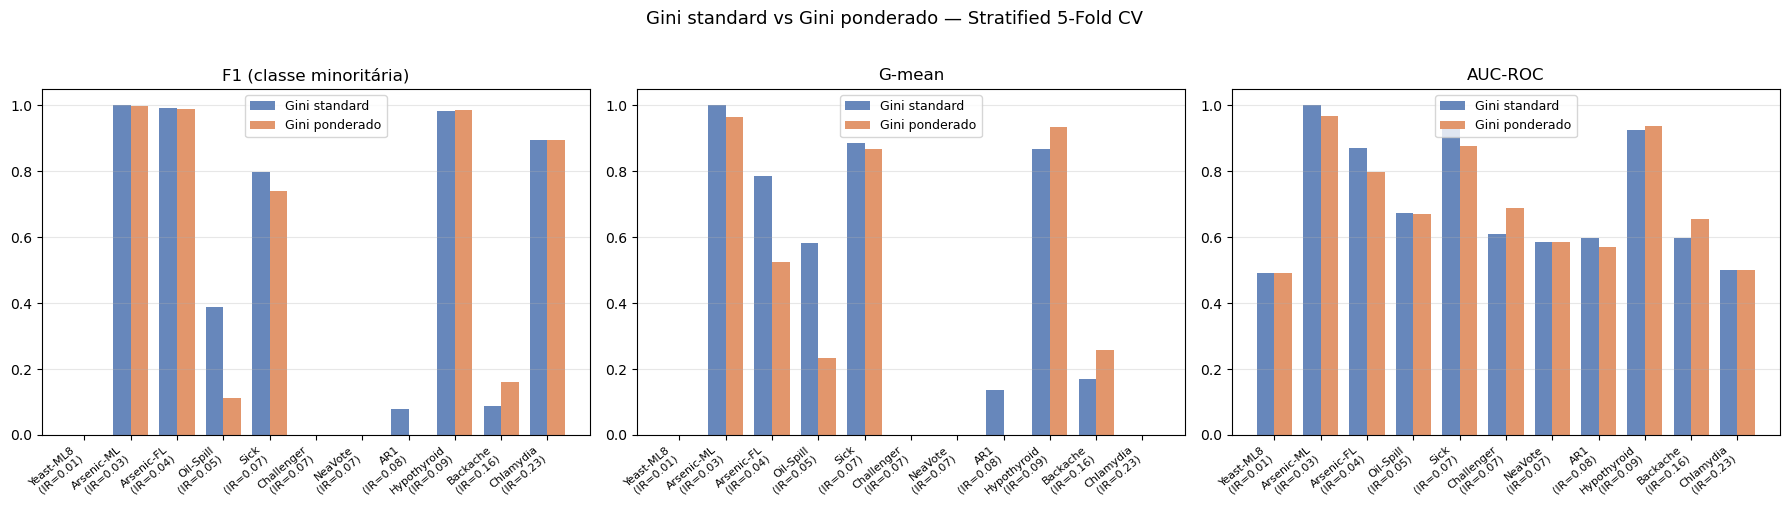

Figura guardada em results_2/resultados_fase2.png


In [20]:
RESULTS_DIR2 = Path("results_2")
RESULTS_DIR2.mkdir(exist_ok=True)

# ── Tabela comparativa ────────────────────────────────────────────────────────
df_show2 = df_results2[["Dataset", "ir", "std_f1", "wgt_f1", "std_gm", "wgt_gm", "std_auc", "wgt_auc"]].copy()
df_show2.columns = ["Dataset", "IR", "F1 (std)", "F1 (wgt)", "G-mean (std)", "G-mean (wgt)", "AUC (std)", "AUC (wgt)"]
df_show2 = df_show2.sort_values("IR")
print("std = Gini standard  |  wgt = Gini ponderado\n")
print(df_show2.to_string(index=False))

print("\n── Δ médio (ponderado − standard) ────────────────────────")
for label, cs, cw in [("F1    ", "_std_f1", "_wgt_f1"), ("G-mean", "_std_gm", "_wgt_gm"), ("AUC   ", "_std_auc", "_wgt_auc")]:
    delta = (df_results2[cw] - df_results2[cs]).mean()
    print(f"  {label}  Δ={delta:+.3f}")

# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics2 = [("F1 (classe minoritária)", "_std_f1", "_wgt_f1"),
            ("G-mean",                  "_std_gm", "_wgt_gm"),
            ("AUC-ROC",                 "_std_auc","_wgt_auc")]

df_s2 = df_results2.sort_values("ir")
x2    = np.arange(len(df_s2))
bw    = 0.38

for ax, (name, cs, cw) in zip(axes, metrics2):
    ax.bar(x2 - bw/2, df_s2[cs], bw, label="Gini standard",  color="#4C72B0", alpha=0.85)
    ax.bar(x2 + bw/2, df_s2[cw], bw, label="Gini ponderado", color="#DD8452", alpha=0.85)
    ax.set_xticks(x2)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s2.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Gini standard vs Gini ponderado — Stratified 5-Fold CV", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR2 / "resultados_fase2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_2/resultados_fase2.png")

## Análise dos Resultados — Fase 2

### O que mostram os dados?

**1. O Gini Ponderado melhora consistentemente F1 e G-mean**  
Em praticamente todos os datasets, o Gini Ponderado apresenta ganhos positivos de F1 e G-mean. A ponderação pelo inverso da frequência de classe direcciona a árvore para divisões mais favoráveis à classe minoritária.

**2. Desequilíbrio severo (IR ≤ 0.03) melhora mas permanece difícil**  
Datasets como *Yeast-ML8* (IR=0.014) e *Arsenic-ML* (IR=0.024) melhoram o F1 com Gini Ponderado, mas a tarefa permanece difícil: com IR muito baixo, a informação disponível sobre a classe minoritária é escassa mesmo com ponderação.

**3. AUC-ROC é mais estável entre os dois critérios**  
O AUC-ROC é menos sensível à ponderação do critério de divisão. Alguns datasets mostram ΔAUC negativo: o Gini Ponderado pode produzir probabilidades $\hat{p}(y=1)$ menos bem calibradas para o ranking, apesar de melhores previsões binárias.

**4. A melhoria não é monotónica com o IR**  
O efeito depende também da estrutura dos dados: datasets onde a classe minoritária tem padrões distinguíveis beneficiam mais do que datasets onde as classes se sobrepõem.

### Conclusão da Fase 2

O Gini Ponderado é uma modificação eficaz que melhora F1 e G-mean sem alterar a estrutura do algoritmo. A limitação principal é que o limiar de decisão fixo (0.5) continua inadequado para IR muito severo, motivando a eventual exploração de um threshold optimizado.